# Rolling


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("../07-Data_visualization/data/stony_brook_daily_temperature_2025.csv")

# Convert Celsius → Fahrenheit
df["temp_F"] = df["average_temperature"] * 9/5 + 32
df['date'] = pd.to_datetime('2025-' + df['month'].astype(str) + '-' + df['day'].astype(str))

df

,month,day,average_temperature,temp_F,date
0,1,1,7.5,45.50,2025-01-01
1,1,2,3.3,37.94,2025-01-02
2,1,3,0.6,33.08,2025-01-03
3,1,4,-1.5,29.30,2025-01-04
4,1,5,-2.3,27.86,2025-01-05
...,...,...,...,...,...
360,12,27,-3.3,26.06,2025-12-27
361,12,28,-2.8,26.96,2025-12-28
362,12,29,5.8,42.44,2025-12-29
363,12,30,-1.2,29.84,2025-12-30


## Basic rolling
### Moving Average (3-day window)
- `window`: number of observations
- First few values = `NaN` (not enough data)

In [3]:
df["temp_3day_avg"] = df["temp_F"].rolling(window=3).mean()

df

,month,day,average_temperature,temp_F,date,temp_3day_avg
0,1,1,7.5,45.50,2025-01-01,NaN
1,1,2,3.3,37.94,2025-01-02,NaN
2,1,3,0.6,33.08,2025-01-03,38.84
3,1,4,-1.5,29.30,2025-01-04,33.44
4,1,5,-2.3,27.86,2025-01-05,30.08
...,...,...,...,...,...,...
360,12,27,-3.3,26.06,2025-12-27,28.64
361,12,28,-2.8,26.96,2025-12-28,25.22
362,12,29,5.8,42.44,2025-12-29,31.82
363,12,30,-1.2,29.84,2025-12-30,33.08


### Rolling Sum
Total temperature over last 3 days

In [6]:
df["temp_3day_sum"] = df["temp_F"].rolling(window=3).sum()

df[['date','temp_F','temp_3day_sum']]

,date,temp_F,temp_3day_sum
0,2025-01-01,45.50,NaN
1,2025-01-02,37.94,NaN
2,2025-01-03,33.08,116.52
3,2025-01-04,29.30,100.32
4,2025-01-05,27.86,90.24
...,...,...,...
360,2025-12-27,26.06,85.92
361,2025-12-28,26.96,75.66
362,2025-12-29,42.44,95.46
363,2025-12-30,29.84,99.24


### Rolling Min / Max
Useful for detecting extremes

In [8]:
df["temp_3day_min"] = df["temp_F"].rolling(window=3).min()
df["temp_3day_max"] = df["temp_F"].rolling(window=3).max()

df[['date','temp_F','temp_3day_min','temp_3day_max']]

,date,temp_F,temp_3day_min,temp_3day_max
0,2025-01-01,45.50,NaN,NaN
1,2025-01-02,37.94,NaN,NaN
2,2025-01-03,33.08,33.08,45.50
3,2025-01-04,29.30,29.30,37.94
4,2025-01-05,27.86,27.86,33.08
...,...,...,...,...
360,2025-12-27,26.06,22.64,37.22
361,2025-12-28,26.96,22.64,26.96
362,2025-12-29,42.44,26.06,42.44
363,2025-12-30,29.84,26.96,42.44


## Centered Rolling Window
- Default: window looks backward
- `center=True`: window is centered

In [9]:
df["temp_centered_avg"] = df["temp_F"].rolling(window=3, center=True).mean()

df[['date', 'temp_F', 'temp_3day_avg', 'temp_centered_avg']]

,date,temp_F,temp_3day_avg,temp_centered_avg
0,2025-01-01,45.50,NaN,NaN
1,2025-01-02,37.94,NaN,38.84
2,2025-01-03,33.08,38.84,33.44
3,2025-01-04,29.30,33.44,30.08
4,2025-01-05,27.86,30.08,28.34
...,...,...,...,...
360,2025-12-27,26.06,28.64,25.22
361,2025-12-28,26.96,25.22,31.82
362,2025-12-29,42.44,31.82,33.08
363,2025-12-30,29.84,33.08,33.08


## Handle Missing Values (`min_periods`)
- Avoid `NaNs` at beginning
- Compute with fewer observations

In [ ]:
df["temp_avg_min1"] = df["temp_F"].rolling(window=3, min_periods=1).mean()

df[['date', 'temp_F', 'temp_3day_avg', 'temp_avg_min1']]

## Rolling Standard Deviation (Volatility)

In [ ]:
df["temp_3day_std"] = df["temp_F"].rolling(window=3).std()

df[['date', 'temp_F', 'temp_3day_std']]

## Rolling with Datetime Window
First, we need to set datetime column as index.

`window="5D"` is equivalent to `window=pd.Timedelta(days=5)`
Note:
- For window that is specified by an integer, `min_periods` will default to the size of the window.
- For window that is specified by an offset/string/timedelta, `min_periods` will default to 1. That's why in the following cell, we don't see `NaN` at the beginning.

In [ ]:
df_with_datetime_index = df.set_index("date")

df_with_datetime_index["temp_5day_avg"] = df_with_datetime_index["temp_F"].rolling(window="5D").mean()

df_with_datetime_index[['temp_F','temp_5day_avg']]

## Rolling operation smoothens data

Let's see how the volatility of seven days change over time.

Note: we observe that 7, 14, and 25 day average follows the same trend of the daily temperature, but much more smooth. It helps reveal trends

In [ ]:
df['temp_7day_avg'] = df['temp_F'].rolling(window=7, min_periods=1, center=False).mean()
df['temp_14day_avg'] = df['temp_F'].rolling(window=14, min_periods=1, center=False).mean()
df['temp_25day_avg'] = df['temp_F'].rolling(window=25, min_periods=1, center=False).mean()

sns.relplot(kind='line', data=df.melt(id_vars='date',
                                      value_vars=['temp_F', 'temp_7day_avg', 'temp_14day_avg','temp_25day_avg'],
                                      value_name="temperature"),
            x='date', y='temperature', hue='variable',
            height=5, aspect=2)


## Rolling with `step`
`step` can reduce output size (for performance and storage). Useful for downsampling for big datasets, faster plotting, or batch process.

In [10]:
df['temp_3day_avg_2step']=df['temp_F'].rolling(window=3, step=2).mean()

df[['date','temp_F','temp_3day_avg', 'temp_3day_avg_2step']]

,date,temp_F,temp_3day_avg,temp_3day_avg_2step
0,2025-01-01,45.50,NaN,NaN
1,2025-01-02,37.94,NaN,NaN
2,2025-01-03,33.08,38.84,38.84
3,2025-01-04,29.30,33.44,NaN
4,2025-01-05,27.86,30.08,30.08
...,...,...,...,...
360,2025-12-27,26.06,28.64,28.64
361,2025-12-28,26.96,25.22,NaN
362,2025-12-29,42.44,31.82,31.82
363,2025-12-30,29.84,33.08,NaN


Another example: if we only want average temperature per 15 days:

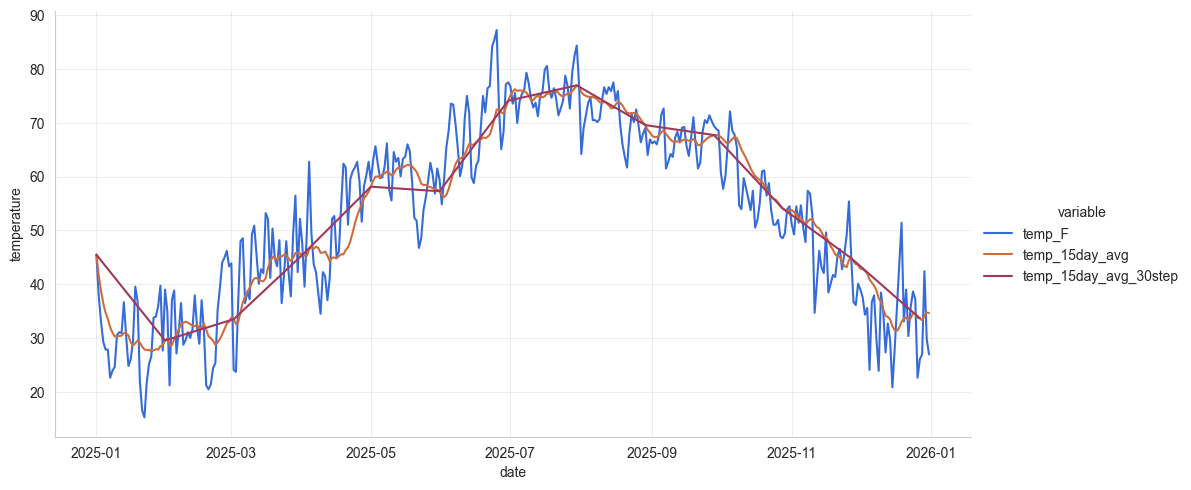

In [12]:
df['temp_15day_avg'] = df['temp_F'].rolling(window=15, min_periods=1).mean()
df['temp_15day_avg_30step'] = df['temp_F'].rolling(window=15, min_periods=1, step=30).mean()

sns.set_style("whitegrid")

sns.relplot(kind='line', data=df.melt(id_vars='date',
                                      value_vars=['temp_F', 'temp_15day_avg','temp_15day_avg_30step'],
                                      value_name="temperature"),
            x='date', y='temperature', hue='variable',
            height=5, aspect=2)

## What is `on` used for?
The `on` parameter is used to specify a column name (other than the index) to act as the anchor for the rolling window calculation. it is primarily used for time-based rolling windows.

`df.rolling(window="3D", on='date')['temp_F'].mean()` is equivalent to `df['temp_F'].rolling(window=3).mean()`


In [ ]:
df['temp_3day_avg'] = df.rolling(window="3D", on='date')['temp_F'].mean()

df[['date','temp_F','temp_3day_avg']]

## Custom function for rolling operations

In [ ]:
df['temp_3day_avg'] = df['temp_F'].rolling(window=3).mean()
df['temp_3day_avg_custom_func']=df['temp_F'].rolling(window=3).apply(lambda x: x.sum()/len(x))

df[['date','temp_F','temp_3day_avg','temp_3day_avg_custom_func']]

## Grouped rolling

In [ ]:
df2 = df.groupby('month', as_index=False)['temp_F'].rolling(window=3).mean()

df2